In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from garalen.config import ModelConfig
from garalen.simulation import run_simulation
from scipy.signal import find_peaks

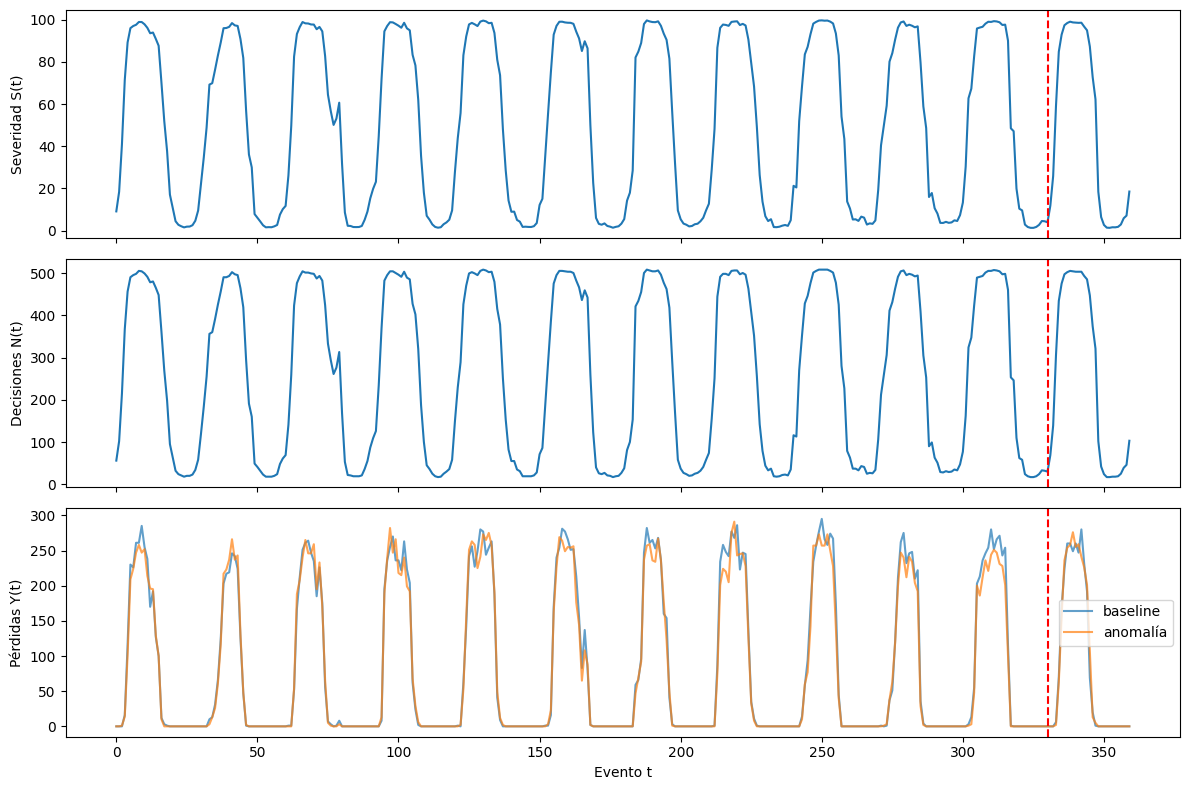

In [2]:
config = ModelConfig()
result = run_simulation(config)

t = np.arange(config.n_periods)

fig, axes = plt.subplots(3, 1, figsize = (12, 8), sharex = True)

axes[0].plot(t, result.S)
axes[0].set_ylabel("Severidad S(t)")
axes[0].axvline(config.t_star, color="red", linestyle="--", label="t_star")

axes[1].plot(t, result.N)
axes[1].set_ylabel("Decisiones N(t)")
axes[1].axvline(config.t_star, color="red", linestyle="--", label="t_star")

axes[2].plot(t, result.Y_baseline, label="baseline", alpha=0.7)
axes[2].plot(t, result.Y_anomaly, label="anomalía", alpha=0.7)
axes[2].set_ylabel("Pérdidas Y(t)")
axes[2].axvline(config.t_star, color="red", linestyle="--")
axes[2].legend()

axes[2].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

In [3]:
print(f"S máximo: {result.S.max():.2f}")
print(f"S mínimo: {result.S.min():.2f}")
print(f"N máximo: {result.N.max()}")
print(f"N mínimo: {result.N.min()}")
print(f"Y_baseline máximo: {result.Y_baseline.max()}")
print(f"Y_baseline mínimo: {result.Y_baseline.min()}")
print(f"Y_anomaly máximo: {result.Y_anomaly.max()}")
print(f"Y_anomaly mínimo: {result.Y_anomaly.min()}")

S máximo: 99.68
S mínimo: 1.35
N máximo: 508
N mínimo: 17
Y_baseline máximo: 295
Y_baseline mínimo: 0
Y_anomaly máximo: 291
Y_anomaly mínimo: 0


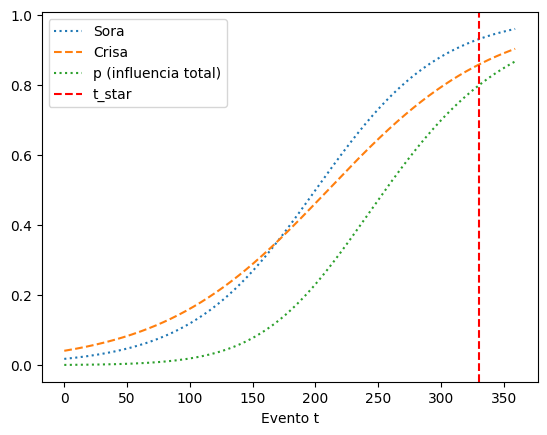

In [4]:
from garalen.losses import _sigmoid

t = np.arange(config.n_periods)
sora = _sigmoid(t, config.k_s, config.t_s)
crisa = _sigmoid(t, config.k_c, config.t_c)
p = sora * crisa

plt.plot(t, sora, label="Sora", linestyle="dotted")
plt.plot(t, crisa, label="Crisa", linestyle="dashed")
plt.plot(t, p, label="p (influencia total)", linestyle="dotted")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.legend()
plt.xlabel("Evento t")
plt.show()

In [5]:
print(f"S máximo: {result.S.max():.2f}")
print(f"S mínimo: {result.S.min():.2f}")
print(f"N máximo: {result.N.max()}")


from garalen.losses import _sigmoid, _failure_probability, _anomaly
N = result.N
q = _failure_probability(N, config)
p = _anomaly(config)
print(f"q máximo: {q.max():.3f}")
print(f"q promedio: {q.mean():.3f}")
print(f"p máximo pre t_star: {p[:config.t_star].max():.3f}")
print(f"p promedio pre t_star: {p[:config.t_star].mean():.3f}")
print(f"q_eff promedio pre t_star: {(q*(1-p))[:config.t_star].mean():.3f}")

S máximo: 99.68
S mínimo: 1.35
N máximo: 508
q máximo: 0.550
q promedio: 0.170
p máximo pre t_star: 0.700
p promedio pre t_star: 0.211
q_eff promedio pre t_star: 0.134


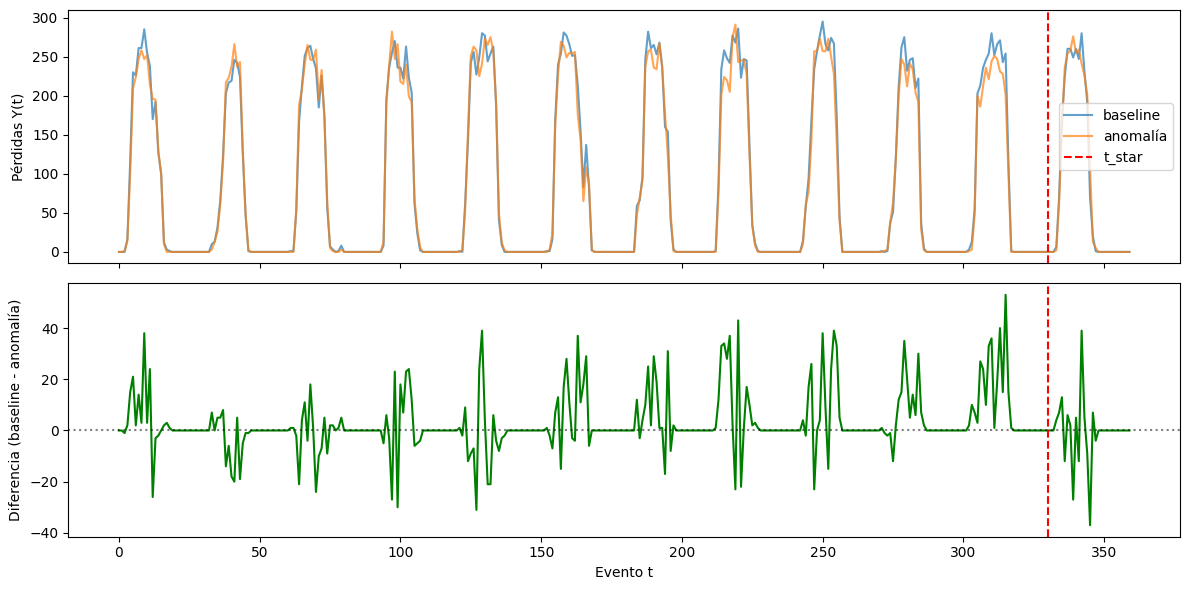

In [6]:
diferencia = result.Y_baseline - result.Y_anomaly

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, result.Y_baseline, label="baseline", alpha=0.7)
axes[0].plot(t, result.Y_anomaly, label="anomalía", alpha=0.7)
axes[0].axvline(config.t_star, color="red", linestyle="--", label="t_star")
axes[0].set_ylabel("Pérdidas Y(t)")
axes[0].legend()

axes[1].plot(t, diferencia, color="green")
axes[1].axvline(config.t_star, color="red", linestyle="--")
axes[1].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Diferencia (baseline - anomalía)")
axes[1].set_xlabel("Evento t")

plt.tight_layout()
plt.show()

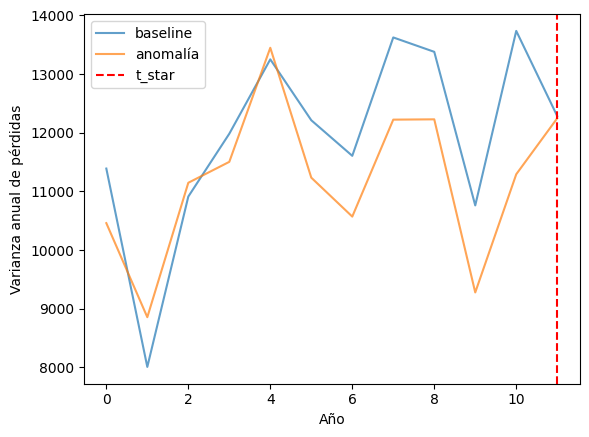

In [7]:
# varianza por año (cada 30 eventos)
eventos_por_año = 30
n_años = config.n_periods // eventos_por_año

var_baseline = []
var_anomaly = []

for i in range(n_años):
    inicio = i * eventos_por_año
    fin = inicio + eventos_por_año
    var_baseline.append(result.Y_baseline[inicio:fin].var())
    var_anomaly.append(result.Y_anomaly[inicio:fin].var())

años = np.arange(n_años)

plt.plot(años, var_baseline, label="baseline", alpha=0.7)
plt.plot(años, var_anomaly, label="anomalía", alpha=0.7)
plt.axvline(config.t_star / eventos_por_año, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza anual de pérdidas")
plt.xlabel("Año")
plt.legend()
plt.show()

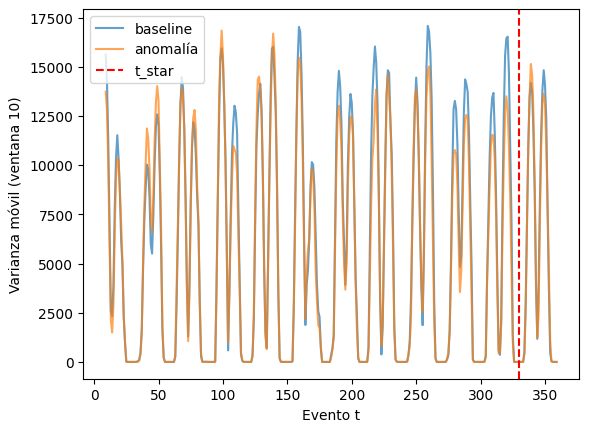

In [8]:
from pandas import Series

var_baseline = Series(result.Y_baseline).rolling(10).var()
var_anomaly = Series(result.Y_anomaly).rolling(10).var()

plt.plot(t, var_baseline, label="baseline", alpha=0.7)
plt.plot(t, var_anomaly, label="anomalía", alpha=0.7)
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza móvil (ventana 10)")
plt.xlabel("Evento t")
plt.legend()
plt.show()

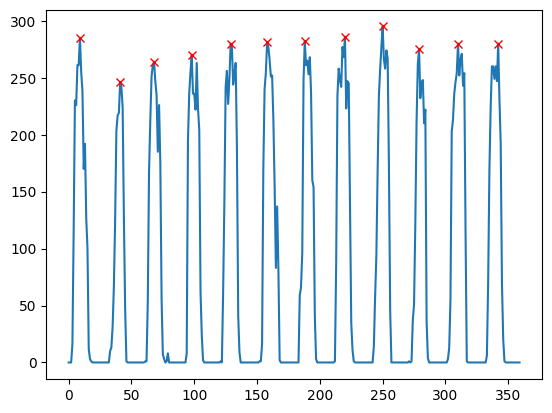

In [9]:
umbral = 2
es_cero = result.Y_baseline <= umbral

# encontrar los índices donde cruza de cero a no-cero y viceversa
cruces = np.diff(es_cero.astype(int))
inicios = np.where(cruces == -1)[0] + 1  # de cero a no-cero
fines = np.where(cruces == 1)[0]         # de no-cero a cero

picos_max = []
centros = []
for ini, fin in zip(inicios, fines):
    if fin > ini:
        segmento = result.Y_baseline[ini:fin]
        idx_max = ini + segmento.argmax()
        picos_max.append(result.Y_baseline[idx_max])
        centros.append(idx_max)

centros = np.array(centros)
picos_max = np.array(picos_max)

plt.plot(t, result.Y_baseline)
plt.plot(centros, picos_max, "x", color="red")
plt.show()

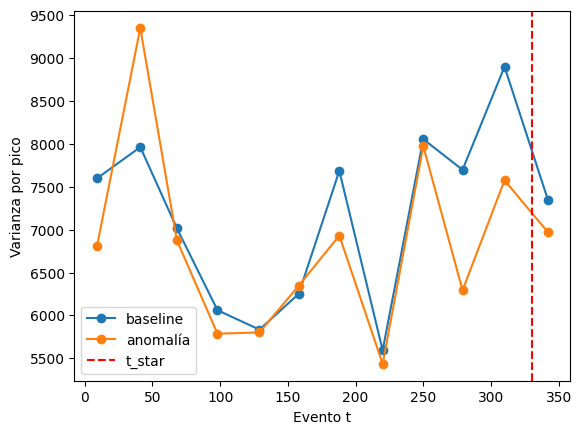

In [10]:
var_baseline_picos = []
var_anomaly_picos = []

for ini, fin in zip(inicios, fines):
    if fin > ini:
        seg_b = result.Y_baseline[ini:fin]
        seg_a = result.Y_anomaly[ini:fin]
        if len(seg_b) > 2:
            var_baseline_picos.append(seg_b.var())
            var_anomaly_picos.append(seg_a.var())

var_baseline_picos = np.array(var_baseline_picos)
var_anomaly_picos = np.array(var_anomaly_picos)

plt.plot(centros, var_baseline_picos, label="baseline", marker="o")
plt.plot(centros, var_anomaly_picos, label="anomalía", marker="o")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza por pico")
plt.xlabel("Evento t")
plt.legend()
plt.show()

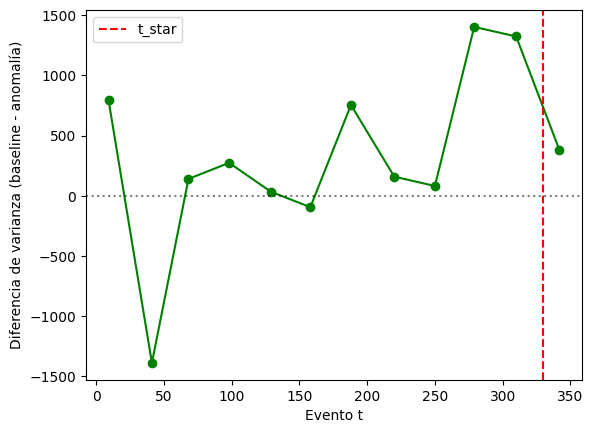

In [11]:
diff_var = np.array(var_baseline_picos) - np.array(var_anomaly_picos)

plt.plot(centros, diff_var, marker="o", color="green")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.axhline(0, color="black", linestyle=":", alpha=0.5)
plt.ylabel("Diferencia de varianza (baseline - anomalía)")
plt.xlabel("Evento t")
plt.legend()
plt.show()

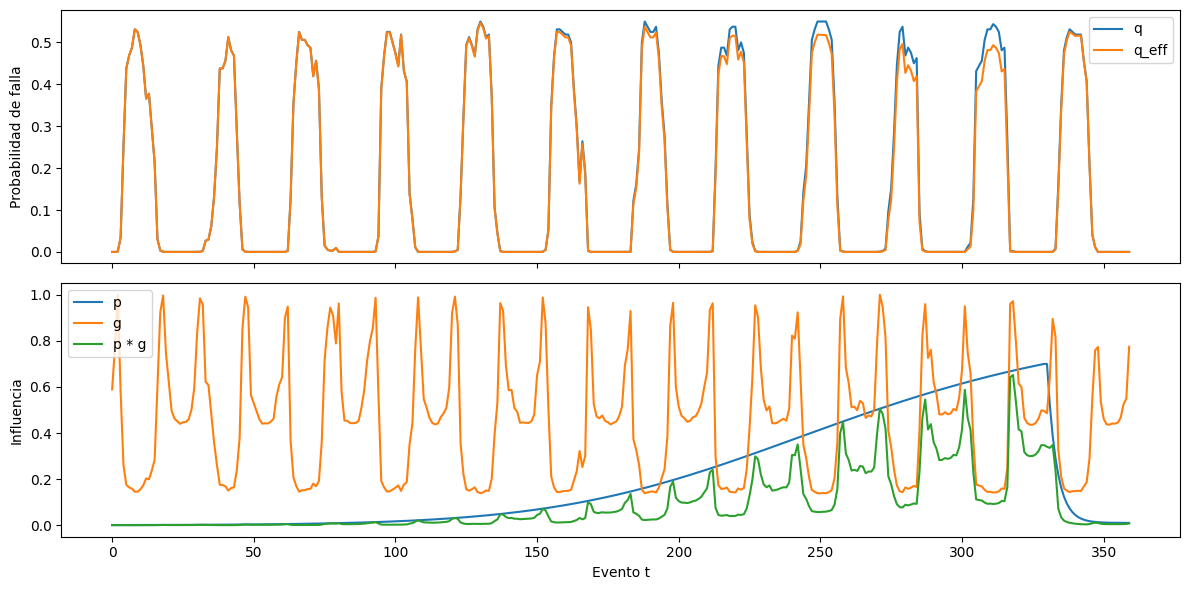

In [12]:
from garalen.losses import _sigmoid, _failure_probability, _anomaly

q = _failure_probability(result.N, config)
p = _anomaly(config)
g = np.exp(-0.5 * ((result.S - config.S_0) / config.sigma_g) ** 2)
q_eff = q * (1 - p * g)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, q, label="q")
axes[0].plot(t, q_eff, label="q_eff")
axes[0].set_ylabel("Probabilidad de falla")
axes[0].legend()

axes[1].plot(t, p, label="p")
axes[1].plot(t, g, label="g")
axes[1].plot(t, p * g, label="p * g")
axes[1].set_ylabel("Influencia")
axes[1].legend()

axes[1].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

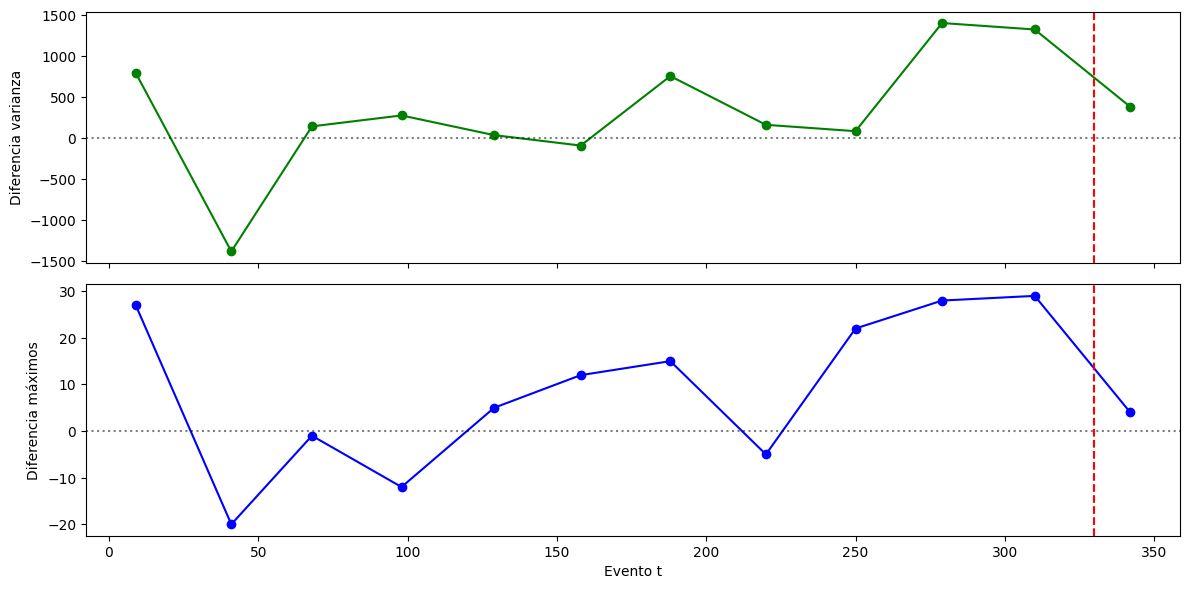

In [13]:
max_baseline = np.array([result.Y_baseline[ini:fin].max() for ini, fin in zip(inicios, fines) if fin > ini])
max_anomaly = np.array([result.Y_anomaly[ini:fin].max() for ini, fin in zip(inicios, fines) if fin > ini])

diff_max = max_baseline - max_anomaly
diff_var = np.array(var_baseline_picos) - np.array(var_anomaly_picos)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(centros, diff_var, marker="o", color="green")
axes[0].axvline(config.t_star, color="red", linestyle="--")
axes[0].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Diferencia varianza")

axes[1].plot(centros, diff_max, marker="o", color="blue")
axes[1].axvline(config.t_star, color="red", linestyle="--")
axes[1].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Diferencia máximos")
axes[1].set_xlabel("Evento t")

plt.tight_layout()
plt.show()

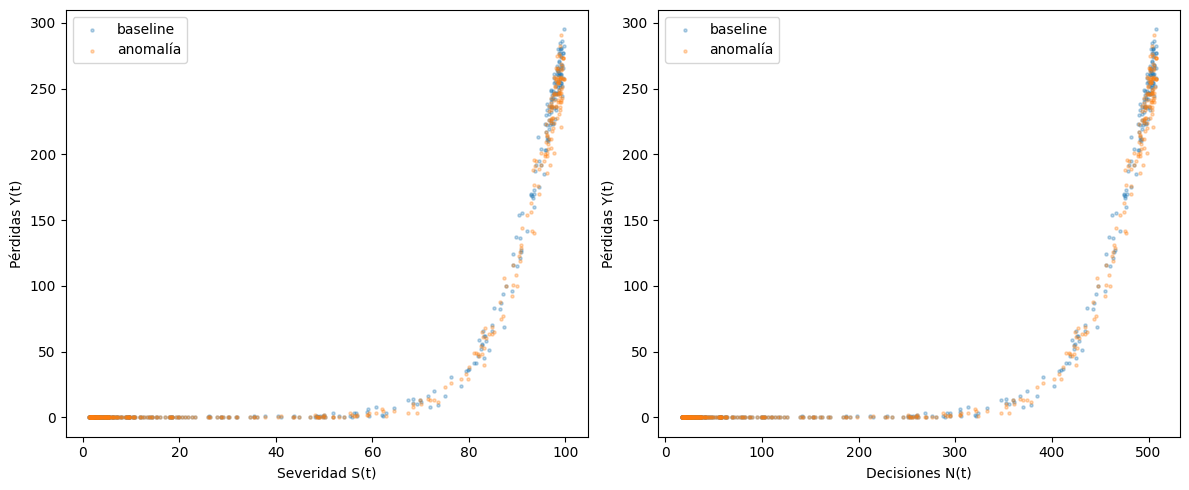

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(result.S, result.Y_baseline, alpha=0.3, s=5, label="baseline")
axes[0].scatter(result.S, result.Y_anomaly, alpha=0.3, s=5, label="anomalía")
axes[0].set_xlabel("Severidad S(t)")
axes[0].set_ylabel("Pérdidas Y(t)")
axes[0].legend()

axes[1].scatter(result.N, result.Y_baseline, alpha=0.3, s=5, label="baseline")
axes[1].scatter(result.N, result.Y_anomaly, alpha=0.3, s=5, label="anomalía")
axes[1].set_xlabel("Decisiones N(t)")
axes[1].set_ylabel("Pérdidas Y(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
print(f"g promedio: {g.mean():.3f}")
print(f"g en S bajo (S<30): {g[result.S < 30].mean():.3f}")
print(f"g en S alto (S>70): {g[result.S > 70].mean():.3f}")
print(f"p promedio: {p.mean():.3f}")
print(f"p en S bajo (S<30): {p[result.S < 30].mean():.3f}")
print(f"p en S alto (S>70): {p[result.S > 70].mean():.3f}")
print(f"p*g promedio pre t_star: {(p*g)[:config.t_star].mean():.3f}")
print(f"p máximo pre t_star: {p[:config.t_star].max():.3f}")

g promedio: 0.452
g en S bajo (S<30): 0.554
g en S alto (S>70): 0.216
p promedio: 0.201
p en S bajo (S<30): 0.214
p en S alto (S>70): 0.188
p*g promedio pre t_star: 0.095
p máximo pre t_star: 0.700
